In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# Comparison of Grid Generation: `N` vs `N+1`
hbar = 1
m = 1
a = 1
U0 = 10
N = 100
# Grid calculations
x = np.linspace(0, a, N)
x1 = np.linspace(0, a, N + 1)
dx = x[1] - x[0]
dx1 = x1[1] - x1[0]

print("for np.linspace(0, a, N)")
print("x=", x)
print("x=", dx)

print("\nfor np.linspace(0, a, N+1)")
print("x1=", x1)
print("dx1=", dx1)

for np.linspace(0, a, N)
x= [0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909 0.1010101  0.11111111
 0.12121212 0.13131313 0.14141414 0.15151515 0.16161616 0.17171717
 0.18181818 0.19191919 0.2020202  0.21212121 0.22222222 0.23232323
 0.24242424 0.25252525 0.26262626 0.27272727 0.28282828 0.29292929
 0.3030303  0.31313131 0.32323232 0.33333333 0.34343434 0.35353535
 0.36363636 0.37373737 0.38383838 0.39393939 0.4040404  0.41414141
 0.42424242 0.43434343 0.44444444 0.45454545 0.46464646 0.47474747
 0.48484848 0.49494949 0.50505051 0.51515152 0.52525253 0.53535354
 0.54545455 0.55555556 0.56565657 0.57575758 0.58585859 0.5959596
 0.60606061 0.61616162 0.62626263 0.63636364 0.64646465 0.65656566
 0.66666667 0.67676768 0.68686869 0.6969697  0.70707071 0.71717172
 0.72727273 0.73737374 0.74747475 0.75757576 0.76767677 0.77777778
 0.78787879 0.7979798  0.80808081 0.81818182 0.82828283 0.83838384
 0.84848485 0.85858586 0.86868687 0

# Grid Discretization: Points vs. Intervals in NumPy

The core difference between `np.linspace(0, a, N)` and `np.linspace(0, a, N+1)` comes down to whether $N$ is defined as the **total number of spatial grid points** or the **number of sub-intervals** (steps).

---

## Comparison Table

| Parameter | Method 1: `np.linspace(0, a, N)` | Method 2: `np.linspace(0, a, N+1)` |
| :--- | :--- | :--- |
| **Interpretation of $N$** | $N$ represents total **grid points** ($N = 10$). | $N$ represents total **intervals** ($N = 10$, so total points $= N + 1 = 11$). |
| **Grid Spacing ($\Delta x$) Formula** | $\Delta x = \frac{a}{N - 1} = \frac{1.0}{9} \approx 0.1111$ | $\Delta x = \frac{a}{N} = \frac{1.0}{10} = 0.1000$ |
| **Resulting Grid Array** | `[0.0, 0.111, 0.222, ..., 1.0]` (9 intervals) | `[0.0, 0.1, 0.2, ..., 1.0]` (10 intervals) |

---

## Implementation Guidelines

* **When to use `np.linspace(0, a, N+1)`:** Use this approach when you want a clean, predefined step size $\Delta x$ (such as $0.1$ or $0.01$). Passing $N+1$ guarantees that $\Delta x = \frac{a}{N}$.
* **When to use `np.linspace(0, a, N)`:** Use this approach when $N$ is explicitly constrained to be the exact dimension of your spatial vector or grid size, yielding $\Delta x = \frac{a}{N - 1}$.

> **Key Rule:** Both formulations are mathematically valid for finite difference calculations as long as your code calculates the step size dynamically (`dx = x[1] - x[0]`) rather than using a hardcoded value.

In [19]:
# create a list of potential
xp = np.linspace(dx1, a-dx1, N-1)

In [20]:
# Potential Energy array V(x)
U = np.linspace(dx, a-dx, N-1)
for i in range(len(U)):
    U[i] = 0
    if xp[i] > a/2:
        U[i] = U0
print(U)

[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10.]


In [21]:
# Off_diagonals above main diagonal 
Ha = np.diag(-hbar**2/(2*m*dx1**2)*np.ones(N-2), 1)
print(Ha)

[[    0. -5000.     0. ...     0.     0.     0.]
 [    0.     0. -5000. ...     0.     0.     0.]
 [    0.     0.     0. ...     0.     0.     0.]
 ...
 [    0.     0.     0. ...     0. -5000.     0.]
 [    0.     0.     0. ...     0.     0. -5000.]
 [    0.     0.     0. ...     0.     0.     0.]]


In [22]:
# Off diagonals below main diagonal 
Hb = np.diag(-hbar**2/(2*m*dx1**2)*np.ones(N-2), -1)
print(Hb)

[[    0.     0.     0. ...     0.     0.     0.]
 [-5000.     0.     0. ...     0.     0.     0.]
 [    0. -5000.     0. ...     0.     0.     0.]
 ...
 [    0.     0.     0. ...     0.     0.     0.]
 [    0.     0.     0. ... -5000.     0.     0.]
 [    0.     0.     0. ...     0. -5000.     0.]]


In [23]:
# main diagonal 
Hm = np.diag(-hbar**2/(m*dx1**2)*np.ones(N-1) + U) 
print(Hm)

[[-10000.      0.      0. ...      0.      0.      0.]
 [     0. -10000.      0. ...      0.      0.      0.]
 [     0.      0. -10000. ...      0.      0.      0.]
 ...
 [     0.      0.      0. ...  -9990.      0.      0.]
 [     0.      0.      0. ...      0.  -9990.      0.]
 [     0.      0.      0. ...      0.      0.  -9990.]]


In [24]:
Ht = Hb + Ha + Hm
print(Ht)

[[-10000.  -5000.      0. ...      0.      0.      0.]
 [ -5000. -10000.  -5000. ...      0.      0.      0.]
 [     0.  -5000. -10000. ...      0.      0.      0.]
 ...
 [     0.      0.      0. ...  -9990.  -5000.      0.]
 [     0.      0.      0. ...  -5000.  -9990.  -5000.]
 [     0.      0.      0. ...      0.  -5000.  -9990.]]


In [25]:
H = np.diag(hbar**2/(m*dx1**2)*np.ones(N-1) + U) + np.diag(-hbar**2/(2*m*dx1**2)*np.ones(N-2), 1) + np.diag(-hbar**2/(2*m*dx1**2)*np.ones(N-2), -1)
print(H)
print(H.shape)

[[10000. -5000.     0. ...     0.     0.     0.]
 [-5000. 10000. -5000. ...     0.     0.     0.]
 [    0. -5000. 10000. ...     0.     0.     0.]
 ...
 [    0.     0.     0. ... 10010. -5000.     0.]
 [    0.     0.     0. ... -5000. 10010. -5000.]
 [    0.     0.     0. ...     0. -5000. 10010.]]
(99, 99)


In [26]:
#Kinetic energy coefficient
c = hbar**2 / (2 * m * dx1**2)

# Main diagonal: 2*c + potential U
main_diag = 2 * c * np.ones(N - 1) + U

# Off diagonals: -c
off_diag = -c * np.ones(N - 2)

# Construct Hamiltonian H
H = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)

print("Hamiltonian Matrix H (shape:", H.shape, "):\n")
print(np.round(H, 2))

Hamiltonian Matrix H (shape: (99, 99) ):

[[10000. -5000.     0. ...     0.     0.     0.]
 [-5000. 10000. -5000. ...     0.     0.     0.]
 [    0. -5000. 10000. ...     0.     0.     0.]
 ...
 [    0.     0.     0. ... 10010. -5000.     0.]
 [    0.     0.     0. ... -5000. 10010. -5000.]
 [    0.     0.     0. ...     0. -5000. 10010.]]


In [27]:
# Calculate eigenvalues and eigenvectors for a symmetric/Hermitian matrix
E, psi = np.linalg.eigh(H)

# Print the ground state energy (the lowest eigenvalue)
print("E[0]=", E[0])

E[0]= 8.659466825237063


psi[0]=
 [-0.00643718 -0.0128632  -0.01926695 -0.02563733 -0.03196331 -0.03823394
 -0.04443834 -0.05056579 -0.05660566 -0.06254749 -0.068381   -0.07409608
 -0.07968283 -0.08513158 -0.0904329  -0.09557759 -0.10055675 -0.10536176
 -0.10998429 -0.11441635 -0.11865024 -0.12267865 -0.12649459 -0.13009145
 -0.13346301 -0.13660343 -0.13950726 -0.14216948 -0.14458548 -0.14675107
 -0.14866251 -0.15031648 -0.15171011 -0.152841   -0.15370719 -0.15430717
 -0.15463991 -0.15470483 -0.15450181 -0.15403122 -0.15329386 -0.15229101
 -0.15102441 -0.14949625 -0.14770918 -0.14566629 -0.14337112 -0.14082765
 -0.13804028 -0.13501385 -0.13175358 -0.12852863 -0.12533815 -0.12218127
 -0.11905714 -0.11596494 -0.11290383 -0.10987299 -0.1068716  -0.10389887
 -0.10095399 -0.09803619 -0.09514466 -0.09227864 -0.08943737 -0.08662007
 -0.083826   -0.0810544  -0.07830453 -0.07557566 -0.07286705 -0.07017797
 -0.06750771 -0.06485555 -0.06222078 -0.05960269 -0.05700057 -0.05441375
 -0.05184151 -0.04928316 -0.04673804 -0.04

Text(0, 0.5, '|psi|^2')

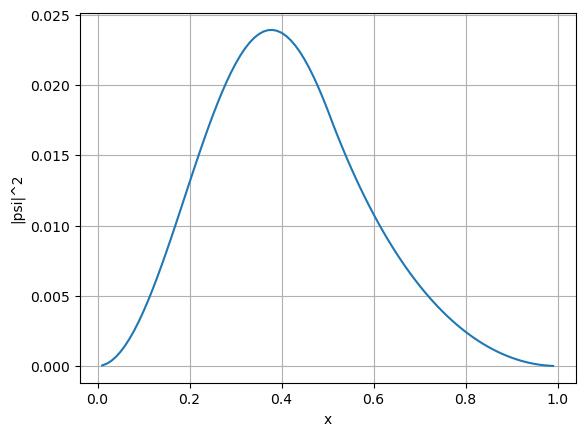

In [28]:
# Print the ground state (the lowest eigenstate)
print("psi[0]=\n", psi.T[0])

# Plot probability density |psi|^2 (always positive)
plt.plot(xp, psi.T[0]**2)
plt.grid()
plt.xlabel('x')
plt.ylabel('|psi|^2')

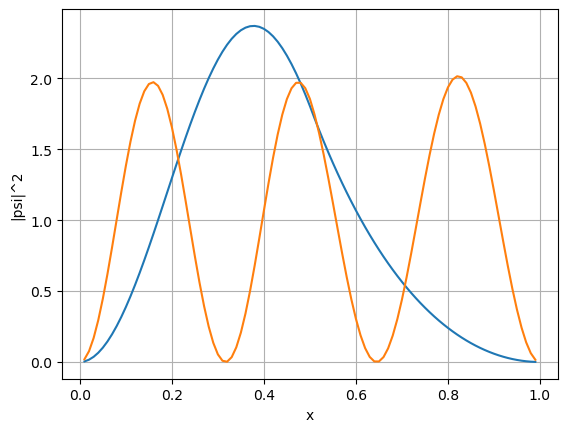

In [39]:
I = np.sum(psi.T[0]**2 * dx)
A = np.sqrt(1 / I)
plt.plot(xp, (A * psi.T[0])**2)

I = np.sum(psi.T[2]**2 * dx)
A = np.sqrt(1 / I)
plt.plot(xp, (A * psi.T[2])**2)

plt.grid()
plt.xlabel('x')
plt.ylabel('|psi|^2')
plt.show()

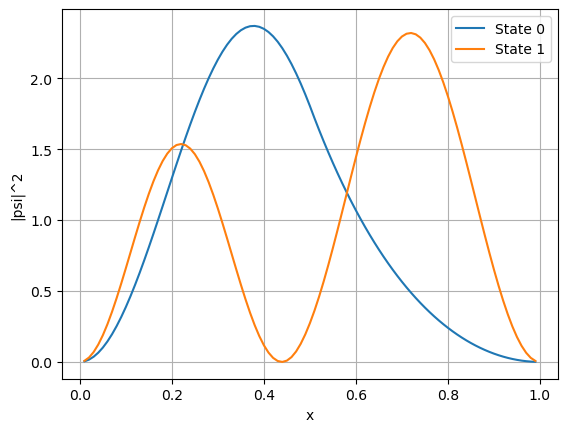

In [40]:
# Loop through the first 2 energy states (ground state and 1st excited state) by loops 
for n in range(2):
    I = np.sum(psi.T[n]**2 * dx)          # Calculate probability integral
    A = np.sqrt(1 / I)                    # Normalization constant
    psi_norm = A * psi.T[n]               # Normalized wavefunction
    plt.plot(xp, psi_norm**2, label=f"State {n}")

plt.grid()
plt.xlabel('x')
plt.ylabel('|psi|^2')
plt.legend()
plt.show()